# Importing Libraries

In [1]:
# Core Data Manipulation
import numpy as np
import pandas as pd

# Machine Learning & Clustering
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

# Data Visualization
import matplotlib.cm as cm
import matplotlib.pyplot as plt

# Geospatial Analysis
import geopandas as gpd

# Loading DF

In [2]:
norm_df = pd.read_csv('..\\Data\\NMF_STREET.csv', low_memory=False)
nyc_map = gpd.read_file("..\\Data\\Modified Zip Code Tabulation Areas (MODZCTA).geojson")
streets_projected = gpd.read_file("..\\Data\\nyc_clustered_streets.gpkg")

# Clustering DBSCAN

In [3]:
# Print clustering output
def output(labels):
    labels = pd.Series(labels)
    print("The labels:", labels)
    print("===================")
    print("Value Counts:\n", labels.value_counts())


A rule proposed by the author of the algorithim is to set the min_samples to = num of dimension + 1 ( 14 in our case ).

But while running the DBSCAN we couldn't get more than 1 cluster doesn't matter which eps we chose, this can be explained by the amount of samples we have ( only 245 incident zips which is not a lot ).

In [56]:

for samp in range(25,27):
    for eps in np.arange(0.2, 2, 0.2):
        db = DBSCAN(eps=eps, min_samples=samp).fit(norm_df.drop("Street_Name", axis=1))
        labels = db.labels_

        # Number of clusters in labels, ignoring noise if present.
        n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise_ = list(labels).count(-1)

        print(f"EPS: {eps:.2f} , min_samples: {samp}")
        print("Number of clusters: %d" % n_clusters_)
        print("Number of noise points: %d" % n_noise_)
        print("--------------")
    print("==============================================")


EPS: 0.20 , min_samples: 25
Number of clusters: 3
Number of noise points: 291
--------------
EPS: 0.40 , min_samples: 25
Number of clusters: 3
Number of noise points: 291
--------------
EPS: 0.60 , min_samples: 25
Number of clusters: 3
Number of noise points: 291
--------------
EPS: 0.80 , min_samples: 25
Number of clusters: 3
Number of noise points: 291
--------------
EPS: 1.00 , min_samples: 25
Number of clusters: 3
Number of noise points: 291
--------------
EPS: 1.20 , min_samples: 25
Number of clusters: 6
Number of noise points: 134
--------------
EPS: 1.40 , min_samples: 25
Number of clusters: 6
Number of noise points: 134
--------------
EPS: 1.60 , min_samples: 25
Number of clusters: 6
Number of noise points: 134
--------------
EPS: 1.80 , min_samples: 25
Number of clusters: 6
Number of noise points: 134
--------------
EPS: 0.20 , min_samples: 26
Number of clusters: 3
Number of noise points: 291
--------------
EPS: 0.40 , min_samples: 26
Number of clusters: 3
Number of noise poin

In [ ]:
# Test run DBSCAN on random hyperparams
# Generate random values
eps_rnd = np.random.uniform(0.1,1)
min_samples_rnd = 15

# min_samples - points required to define a value as a core point
# eps - radious 
db = DBSCAN(eps = eps_rnd, min_samples = 10).fit(norm_df.drop("Street_Name",axis = 1))
labels = db.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print(f"EPS: {eps_rnd:.2f} , min_samples: {min_samples_rnd}")
print("Number of clusters: %d" % n_clusters_)
print("Number of noise points: %d" % n_noise_)

EPS: 0.30 , min_samples: 3
Number of clusters: 1
Number of noise points: 0


After some brief testing we found out that the rule proposed by the author didn't suite our data.

so we chose to use min_samples = 3 since it got the least amount of noise points in the test run. Now we need to find the best value for the eps hyperparameter.

we will do it using the KNN algo with k=3 ( not for predicting but for measuring the distance and finding the best eps for the specific min_samples using the elbow method ).

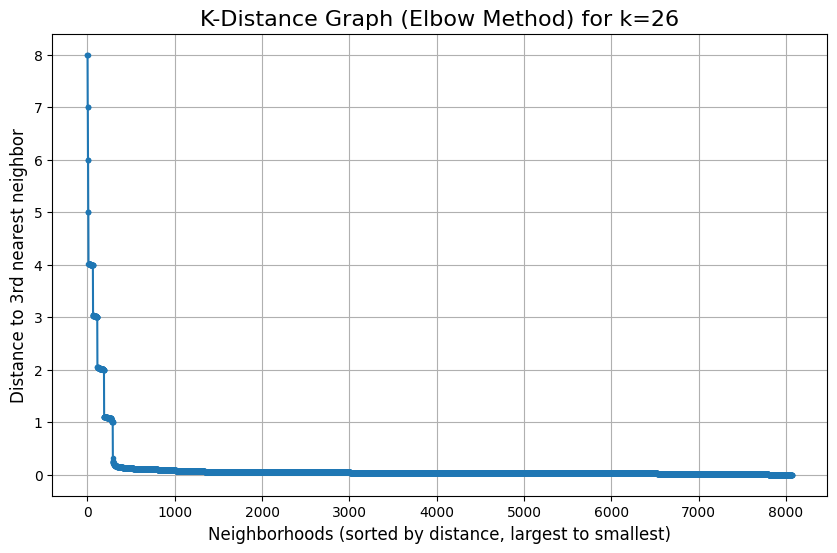

In [54]:
# k is 3 based on the min_samples we chose
k = 26
X_features = norm_df.drop("Street_Name", axis=1).values

# Fit the algorithm on our data
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X_features)

# Calculate distances
distances, indices = neighbors_fit.kneighbors(X_features)

# Extract the distance to the 3th neighbor ( most distant neighbor of the 3 )
k_distances = distances[:, k-1]

# FLIP THE GRAPH: Sort the distances in descending order using [::-1]
k_distances_sorted_desc = np.sort(k_distances)[::-1]

# Lot the flipped K-distance graph
plt.figure(figsize=(10, 6))
plt.plot(k_distances_sorted_desc, marker='.', linestyle='solid')
plt.title(f'K-Distance Graph (Elbow Method) for k={k}', fontsize=16)
plt.xlabel('Neighborhoods (sorted by distance, largest to smallest)', fontsize=12)
plt.ylabel('Distance to 3rd nearest neighbor', fontsize=12)
plt.grid(True)
plt.show()

We can see that between the elbow is between 1.75~ to 2. 

Let's run a for loop on this range of eps values to see which one gets us the better resoults.

In [45]:
# Let's test eps values from 1 up to 10 in increments of 0.25
for eps_value in np.arange(0.01, 0.175, 0.01):
    
    # Run DBSCAN with the current eps and our locked-in min_samples of 14
    db = DBSCAN(eps=eps_value, min_samples = 6).fit(norm_df.drop("Street_Name", axis=1))
    labels = db.labels_
    
    # Calculate clusters and noise
    n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise_ = list(labels).count(-1)

    # Only print results if it found more than 1 cluster
    if n_clusters_ > 1:
        print(f"eps={eps_value:.2f} | Clusters: {n_clusters_} | Noise Points: {n_noise_} -> {(n_noise_/8070)*100:.2f} %") # 245 is the amount of samples

eps=0.01 | Clusters: 22 | Noise Points: 7607 -> 94.26 %
eps=0.02 | Clusters: 32 | Noise Points: 4966 -> 61.54 %
eps=0.03 | Clusters: 33 | Noise Points: 2443 -> 30.27 %
eps=0.04 | Clusters: 24 | Noise Points: 1002 -> 12.42 %
eps=0.05 | Clusters: 17 | Noise Points: 835 -> 10.35 %
eps=0.06 | Clusters: 26 | Noise Points: 734 -> 9.10 %
eps=0.07 | Clusters: 31 | Noise Points: 460 -> 5.70 %
eps=0.08 | Clusters: 21 | Noise Points: 239 -> 2.96 %
eps=0.09 | Clusters: 20 | Noise Points: 187 -> 2.32 %
eps=0.10 | Clusters: 20 | Noise Points: 171 -> 2.12 %
eps=0.11 | Clusters: 20 | Noise Points: 149 -> 1.85 %
eps=0.12 | Clusters: 20 | Noise Points: 140 -> 1.73 %
eps=0.13 | Clusters: 20 | Noise Points: 136 -> 1.69 %
eps=0.14 | Clusters: 20 | Noise Points: 132 -> 1.64 %
eps=0.15 | Clusters: 20 | Noise Points: 132 -> 1.64 %
eps=0.16 | Clusters: 20 | Noise Points: 131 -> 1.62 %
eps=0.17 | Clusters: 20 | Noise Points: 129 -> 1.60 %


We can see that the first optimal eps values for which we get a low amount of noise is for eps=3.5 with 4 clusters.

Let's choose those hyperparameters.

In [64]:
# Running DBSCAN on the parameters we found
db_final = DBSCAN(eps=1.2, min_samples = 26).fit(norm_df.drop("Street_Name",axis = 1))
labels = db_final.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

# Attaching the cluster lablels to the data pre pca and normalization
norm_df["Cluster"] = db_final.labels_

print("Number of clusters: %d" % n_clusters_)
print("Number of noise points: %d" % n_noise_)

Number of clusters: 1
Number of noise points: 0


# Showing the clusters on the map

In [65]:
output(labels)

The labels: 0       0
1       0
2       0
3       0
4       0
       ..
8064    0
8065    0
8066    0
8067    0
8068    0
Length: 8069, dtype: int64
Value Counts:
 0    8069
Name: count, dtype: int64


-1 represents noise and 0 , 1 , 2 , 3 are the clusters.

problem is , most of the values are in the same cluster... not helpful at all. solutions from easiest to hardest:

* not use pca. only normalization.

* try to find better hyperparams

* maybe there are more solutions but i didnt think of any yet

ValueError: aspect must be finite and positive 

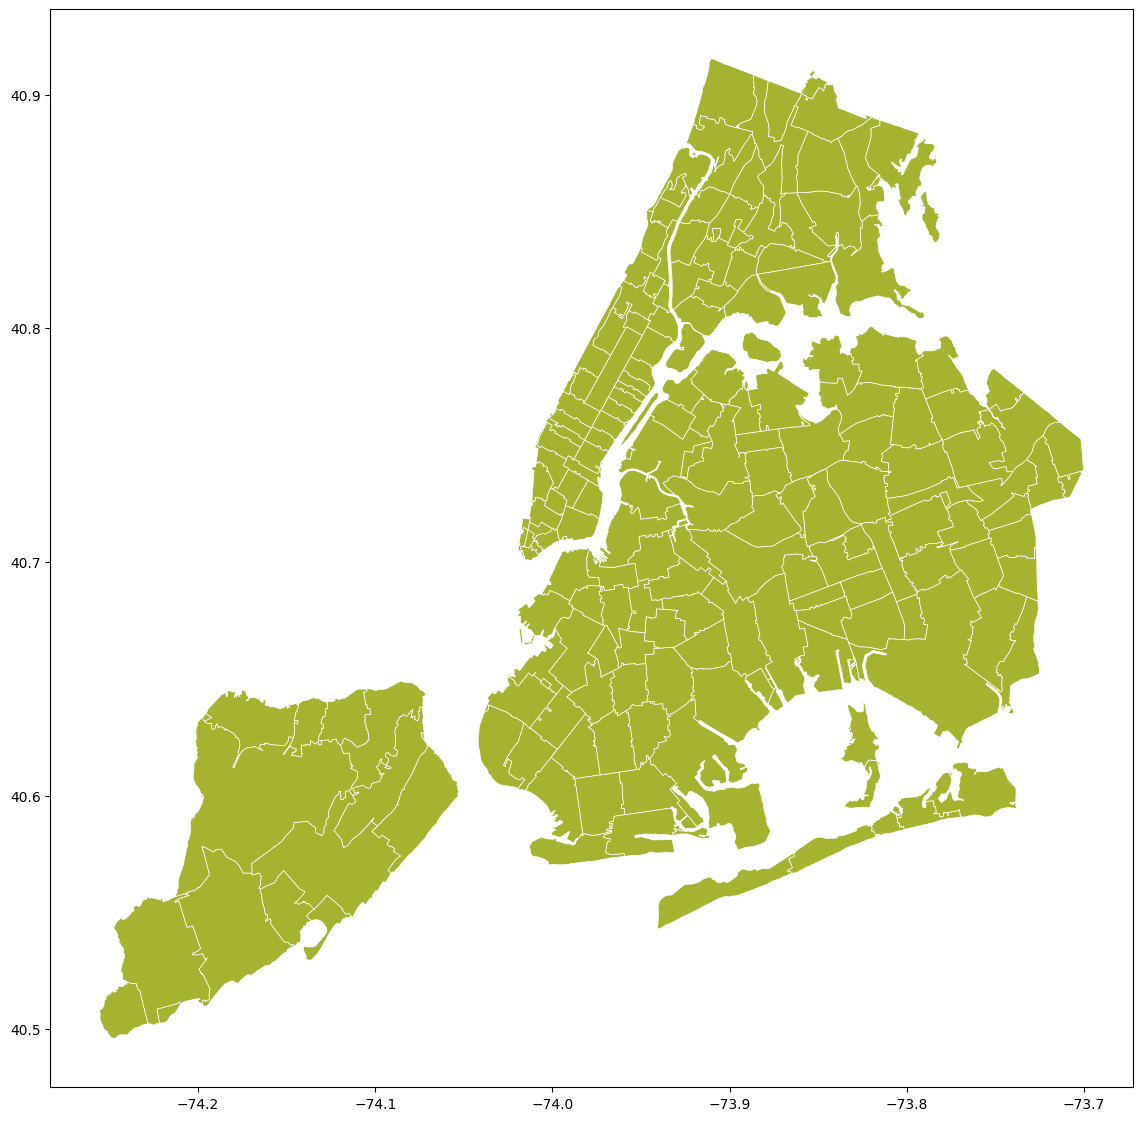

In [9]:
# Prepare the dataframe for the merge
pree_norm_df_final = norm_df.reset_index()

# Cleaning up zip codes to remove decimals and ensure standard format
pree_norm_df_final['Street_Name'] = (
    pree_norm_df_final['Street_Name']
    .astype(str)
    .str.split('.')
    .str[0]
    .str.zfill(5)
)
nyc_map['modzcta'] = nyc_map['modzcta'].astype(str).str.strip()

# This maps point/vanity zips, airports, splits, and former "trash" zips to their parent polygons ( We used an LLM to categorize the zips)
zip_crosswalk = {
    # Midtown Manhattan Vanity Zips
    '10118': '10001', '10119': '10001', '10120': '10001', '10121': '10001', 
    '10122': '10001', '10123': '10001', '10151': '10022', '10152': '10022', 
    '10153': '10022', '10154': '10022', '10155': '10022', '10165': '10017', 
    '10166': '10017', '10167': '10017', '10168': '10017', '10169': '10017', 
    '10170': '10017', '10171': '10017', '10172': '10017', '10173': '10017', 
    '10174': '10017', '10020': '10036', '10041': '10004', '10045': '10005', 
    '10048': '10007', '10055': '10022', '10080': '10007', '10103': '10019', 
    '10105': '10019', '10106': '10019', '10107': '10019', '10110': '10036', 
    '10111': '10036', '10112': '10036', '10115': '10027', '10158': '10017', 
    '10162': '10021', '10175': '10017', '10176': '10017', '10177': '10017', 
    '10178': '10017', '10179': '10017',
    
    # Financial District / Downtown
    '10271': '10005', '10278': '10007', '10279': '10007', '10281': '10280',
    
    # Brooklyn Zips & Splits
    '11249': '11211', '11241': '11201', '11242': '11201', '11251': '11201',
    
    # Queens / Airports / Special Facilities
    '11359': '11360', # Fort Totten
    '11371': '11370', # LaGuardia Airport
    '11430': '11434', # JFK Airport
    '11695': '11691', # Far Rockaway
    '11005': '11004', # Glen Oaks border

    # --- FORMER TRASH ZIPS INCORPORATED HERE ---
    
    # Bordering Nassau & Westchester Counties (Mapped to closest NYC neighborhood)
    '10803': '10475', # Pelham Manor -> mapped to Bronx border
    '11001': '11004', # Floral Park (Nassau) -> mapped to Floral Park (Queens)
    '11021': '11363', # Great Neck -> mapped to Little Neck
    '11040': '11004', # New Hyde Park -> mapped to Floral Park (Queens)
    '11096': '11691', # Inwood (Nassau) -> mapped to Far Rockaway
    '11803': '11426', # Plainview -> mapped to Bellerose (Eastern Queens edge)

    # NYC Vanity, Parks, and Error Defaults
    '00083': '10024', # Central Park -> mapped to Upper West Side
    '10000': '10001', # Generic NYC Error -> mapped to Midtown
    '10400': '10451', # Generic Bronx Error -> mapped to South Bronx

}

# Apply crosswalk maps
pree_norm_df_final['Street_Name'] = pree_norm_df_final['Street_Name'].replace(zip_crosswalk)

# Merge the geographic polygons with the clustering labels
mapped_clusters = nyc_map.merge(
    pree_norm_df_final, 
    left_on='modzcta', 
    right_on='Street_Name', 
    how='inner'
)

# Plot the Choropleth Map
fig, ax = plt.subplots(1, 1, figsize=(14, 14))

# Plot a light grey base map of ALL NYC zip codes behind the data for context
nyc_map.plot(ax=ax, color="#a6b330", edgecolor='white', linewidth=0.5)

# Plot the specific clusters
mapped_clusters.plot(
    column='Cluster', 
    ax=ax, 
    categorical=True, 
    legend=True,
    cmap='tab20c',      # Switched to tab20 to easily handle up to 20 distinct categories
    edgecolor='black',
    linewidth=0.3,
    legend_kwds={
        'loc': 'upper left', 
        'bbox_to_anchor': (1, 1), 
        'title': "Clusters", 
        'fontsize': 11,
        'title_fontsize': 13
    }
)


# Define what makes a cluster "small" (e.g., 3 or fewer ZIP codes)
small_cluster_threshold = 3

# Count how many ZIP codes are in each cluster
cluster_sizes = mapped_clusters['Cluster'].value_counts()

# Identify which cluster IDs are considered "small"
small_cluster_ids = cluster_sizes[cluster_sizes <= small_cluster_threshold].index.tolist()

# Split the dataframe into "Normal" and "Small" clusters
normal_clusters_df = mapped_clusters[~mapped_clusters['Cluster'].isin(small_cluster_ids)]
small_clusters_df = mapped_clusters[mapped_clusters['Cluster'].isin(small_cluster_ids)]

# Start Plotting
fig, ax = plt.subplots(1, 1, figsize=(14, 14))

# Plot the base NYC map first (the background)
nyc_map.plot(ax=ax, color="#e0e0e0", edgecolor='white', linewidth=0.5)

# Plot the NORMAL clusters (using the standard tab20 colormap and normal borders)
normal_clusters_df.plot(
    column='Cluster', 
    ax=ax, 
    categorical=True, 
    legend=True,
    cmap='tab20',
    edgecolor='black',
    linewidth=0.3,
    legend_kwds={
        'loc': 'upper left', 
        'bbox_to_anchor': (1, 1), 
        'title': "Normal Clusters", 
        'fontsize': 11
    }
)

# Plot the SMALL clusters on top with neon colors and NO borders
if not small_clusters_df.empty:
    small_clusters_df.plot(
        column='Cluster', 
        ax=ax, 
        categorical=True, 
        cmap='spring',     # 'spring' gives very bright magenta/yellow/neon colors
        edgecolor='none',  # No borders so the color doesn't get swallowed
        zorder=5           # Forces these polygons to be drawn on top of everything else
    )
    
    # Optional: Print a little alert so you know the code found them
    print(f"Found {len(small_cluster_ids)} small clusters. Highlighted in neon.")
    print(f"Small Cluster IDs: {small_cluster_ids}")


plt.title('NYC 311 Complaint Clusters by Street', fontsize=18, fontweight='bold', pad=20)
plt.axis('off') 
plt.tight_layout()
plt.show()